In [7]:
import sklearn
print(sklearn.__version__)

1.8.0


In [8]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [12]:
# carregando o dataset
digits = load_digits()

# analise x = feature e y = label
x = digits.data
y = digits.target

# exploracao basica
print("Shape de x:", x.shape)
print("Shape de x:", y.shape)
print("Clsses:", digits.target_names)
print("Exemplo de y", y[:10])

Shape de x: (1797, 64)
Shape de x: (1797,)
Clsses: [0 1 2 3 4 5 6 7 8 9]
Exemplo de y [0 1 2 3 4 5 6 7 8 9]


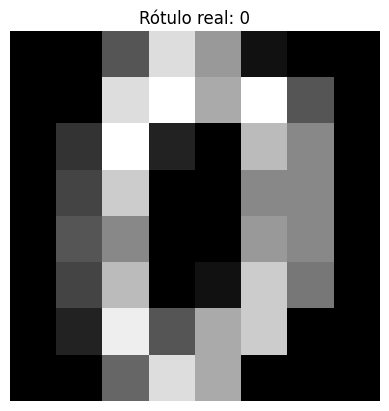

In [13]:
import matplotlib.pyplot as plt

# vamos pegar a primeira imagem e reshape de 64 pixel par ficar com matriz 8x8
imagem = x[0].reshape(8,8)

plt.imshow(imagem, cmap='gray')
plt.title(f"Rótulo real: {y[0]}")
plt.axis('off')
plt.show()

In [14]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

print("Treino:", x_train.shape)
print("Teste:", x_test.shape)

Treino: (1437, 64)
Teste: (360, 64)


In [15]:
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

print("Media após escala:", x_train.mean().round(4))
print("Desvio após escala:", x_train.std().round(4))

Media após escala: 0.0
Desvio após escala: 0.9763


In [16]:
# modelo 1 - regressao logisitca
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(x_train, y_train)

# modelo 2 arvore e decisão
dt = DecisionTreeClassifier(max_depth=10, random_state=42)
dt.fit(x_train, y_train)

# modelo 3 - random forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_train, y_train)

print("3 modelos treinados")

3 modelos treinados


In [17]:
# predicoes dos 3 modelos
y_pred_lr = lr.predict(x_test)
y_pred_dt = dt.predict(x_test)
y_pred_rf = rf.predict(x_test)

# relatorio completo de cada modelo
print("=== REGRESSÃO LOGÍSTICA ===")
print(classification_report(y_test, y_pred_lr))

print("=== ARVORE DE DECISAO ===")
print(classification_report(y_test, y_pred_dt))

print("=== RANDOM FOREST ===")
print(classification_report(y_test, y_pred_rf))

=== REGRESSÃO LOGÍSTICA ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.89      0.89      0.89        36
           2       1.00      1.00      1.00        35
           3       0.97      1.00      0.99        37
           4       0.97      1.00      0.99        36
           5       1.00      1.00      1.00        37
           6       1.00      0.97      0.99        36
           7       1.00      1.00      1.00        36
           8       0.89      0.89      0.89        35
           9       1.00      0.97      0.99        36

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360

=== ARVORE DE DECISAO ===
              precision    recall  f1-score   support

           0       0.94      0.94      0.94        36
           1       0.70      0.72      0.71        36
           2       0.93 

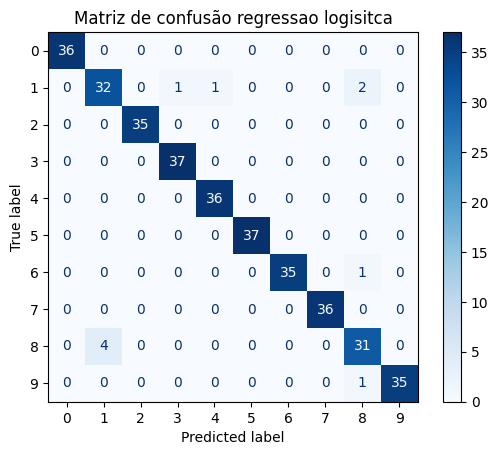

In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=digits.target_names)
disp.plot(cmap='Blues')
plt.title("Matriz de confusão regressao logisitca")
plt.show()

In [19]:
from sklearn.metrics import accuracy_score

modelos = {
    "Regressao logisitca": y_pred_lr,
    "Arvore de decisao":   y_pred_dt,
    "Random forest":       y_pred_rf
}

print(f"{'Modelo':<25}{'Accuracy':>10}{'AUC-ROC':>10}")
print("-" * 47)

for nome, y_pred in modelos.items():
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test,[m.predict_proba(x_test) for m in [lr, dt, rf]][list(modelos.keys()).index(nome)], multi_class='ovr')
    print(f"{nome:<25}{acc:>10.4f}{auc:>10.4f}")



Modelo                     Accuracy   AUC-ROC
-----------------------------------------------
Regressao logisitca          0.9722    0.9991
Arvore de decisao            0.8083    0.8989
Random forest                0.9639    0.9992
